# Portfolio Analyzer

**Author:** Yusuf Ardahan Dogru  
**Date:** December 2025  
**Purpose:** Analyze multi-asset portfolios using Modern Portfolio Theory

## Overview
This notebook explores implementations and outcomes of portfolio optimization techniques that the author is curious about; including:
- Risk-return analysis
- Minimum variance optimization
- Sharpe ratio maximization

The notebook also contains the XGBoost model to forecast stock values

### Library Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


### Style of Visualization

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Stock and ETF tickers

In [3]:
tickers = [
    # Individual stocks (play around with different stocks)
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', # 4 of the Magnificient 7
    'JPM', 'BAC',                    # finance/banking giants
    'WMT', 'AMZN',                   # retail giants ( + 1 Magnif 7)
    'JNJ', 'UNH',                    # healthcare
    'XOM', 'CVX',                    # oil
    
    # Strategic ETFs
    'SCHG',  # Growth
    'SPMO',  # Momentum
    'SMH',   # Semiconductors
    
    # Benchmarks
    'SPY',   # S&P 500
    'AGG'    # Bonds (consider for diversification)
]

### Get ticker data using yf

In [4]:
import os

start_date = '2020-12-01'
end_date = '2025-12-06'

# --- Reproducibility switch -------------------------------------------------
# USE_CACHED = True  -> load saved prices from data_prices.csv (fixed numbers, no network)
# USE_CACHED = False -> pull fresh from yfinance and OVERWRITE data_prices.csv
# Kept True by default so the notebook reproduces the SAME numbers on every run.
USE_CACHED = True
CACHE_FILE = 'data_prices.csv'

if USE_CACHED and os.path.exists(CACHE_FILE):
    # Load the cached raw prices (index = dates, columns = tickers).
    data = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
    print(f"Loaded cached prices from {CACHE_FILE} (USE_CACHED=True)")
else:
    # auto_adjust=True => adjusts historical prices for splits/dividends so returns aren't distorted
    # progress=False    => hides the download progress bar
    raw_data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)

    if isinstance(raw_data.columns, pd.MultiIndex):
        data = raw_data['Close'].copy()
    else:
        data = raw_data.copy()

    # Save the raw pulled prices so future runs can reproduce these exact numbers.
    data.to_csv(CACHE_FILE)
    if USE_CACHED:
        print(f"{CACHE_FILE} not found -> pulled fresh from yfinance and created the cache")
    else:
        print(f"Pulled fresh from yfinance and overwrote {CACHE_FILE} (USE_CACHED=False)")

print(f"Data shape: {data.shape}")
print(f"Date range: From {data.index[0].date()} to {data.index[-1].date()}")

Loaded cached prices from data_prices.csv (USE_CACHED=True)
Data shape: (1260, 17)
Date range: From 2020-12-01 to 2025-12-05


### Handle Missing Values

In [5]:
if (data.isnull().sum()).sum() > 0:
    print(f"\nMissing values per stock:")
    print(data.isnull().sum())
    data = data.ffill()  
# ffill => forward fill => replace with last/preceding val

if len(data) < 100:
    print(f"Warning: Only {len(data)} days of data available")

In [6]:
returns = data.pct_change().dropna()
#pct_change is a pandas Dataframe method, computes: (current_value - previous_value) / previous_value for each column, row by row

print("Daily returns calculated!")
print(f"Shape: {returns.shape}")
print(f"\nSample returns:")
print(returns.head(1))

# Risk-free rate used consistently for every Sharpe ratio in this notebook.
riskFreeRate = 0.04  # 3 month T-bills as the risk-free benchmark.

# Calculate key metrics
annual_returns = returns.mean() * 252  # 252 trading days per year
annual_volatility = returns.std() * np.sqrt(252)
sharpe_ratio = (annual_returns - riskFreeRate) / annual_volatility  # excess return over risk-free, per unit volatility

# Create summary DataFrame
metrics_df = pd.DataFrame({
    'Annual Return (%)': (annual_returns * 100).round(2),
    'Volatility (%)': (annual_volatility * 100).round(2),
    'Sharpe Ratio': sharpe_ratio.round(3)
}).sort_values('Sharpe Ratio', ascending=False)

print("\n" + "="*60)
print("PORTFOLIO METRICS SUMMARY")
print("="*60)
print(metrics_df)

Daily returns calculated!
Shape: (1259, 17)

Sample returns:
                AAPL       AGG     AMZN       BAC       CVX     GOOGL  \
Date                                                                    
2020-12-02  0.002934 -0.001103 -0.00514  0.012896  0.027673  0.016493   

                 JNJ       JPM      MSFT      NVDA      SCHG       SMH  \
Date                                                                     
2020-12-02  0.004679  0.019208 -0.003885  0.011538 -0.001606  0.004002   

                SPMO       SPY      UNH       WMT       XOM  
Date                                                         
2020-12-02 -0.003577  0.002104  0.01867 -0.013889  0.037403  

PORTFOLIO METRICS SUMMARY
       Annual Return (%)  Volatility (%)  Sharpe Ratio
NVDA               65.80           52.06         1.187
XOM                29.92           27.19         0.953
JPM                24.89           24.18         0.864
GOOGL              30.48           31.05         0.853
SPMO    

### Outlier Analysis

We z-score each asset's daily returns and flag any day where **|z| > 3** as an outlier. We **flag and report** these days rather than dropping them: outliers in financial returns often represent real market events (earnings surprises, crashes, Fed announcements), so removing them would discard genuine information and introduce survivorship bias. The table below reports how many outliers each asset has and the single most extreme day per asset.

In [7]:
# OUTLIER ANALYSIS - flag (do NOT remove) extreme daily returns.
# Z-score each asset's daily returns; any day with |z| > 3 is flagged as an outlier.
z_scores = (returns - returns.mean()) / returns.std()
outlier_mask = z_scores.abs() > 3          # boolean DataFrame, same shape as returns

outlier_summary = []
for ticker in returns.columns:
    n_out = int(outlier_mask[ticker].sum())
    if n_out > 0:
        extreme_date = z_scores[ticker].abs().idxmax()     # day with the largest |z| for this asset
        extreme_ret = returns.loc[extreme_date, ticker]
        extreme_z = z_scores.loc[extreme_date, ticker]
        outlier_summary.append({
            'Asset': ticker,
            'Outliers (|z|>3)': n_out,
            'Most Extreme Date': extreme_date.date(),
            'Return (%)': round(extreme_ret * 100, 2),
            'Z-score': round(extreme_z, 2),
        })
    else:
        outlier_summary.append({
            'Asset': ticker, 'Outliers (|z|>3)': 0,
            'Most Extreme Date': None, 'Return (%)': np.nan, 'Z-score': np.nan,
        })

outlier_table = (pd.DataFrame(outlier_summary)
                 .sort_values('Outliers (|z|>3)', ascending=False)
                 .reset_index(drop=True))

total_outliers = int(outlier_mask.sum().sum())
print("="*70)
print("OUTLIER ANALYSIS - daily returns with |z-score| > 3 (FLAGGED, NOT REMOVED)")
print("="*70)
print(f"Total outlier observations: {total_outliers} out of "
      f"{returns.shape[0]} days x {returns.shape[1]} assets = {returns.size} observations\n")
print(outlier_table.to_string(index=False))

OUTLIER ANALYSIS - daily returns with |z-score| > 3 (FLAGGED, NOT REMOVED)
Total outlier observations: 240 out of 1259 days x 17 assets = 21403 observations

Asset  Outliers (|z|>3) Most Extreme Date  Return (%)  Z-score
 AMZN                21        2022-04-29      -14.05    -6.38
  UNH                21        2025-04-17      -22.38   -12.02
  WMT                18        2022-05-17      -11.38    -8.74
  JPM                17        2024-11-06       11.54     7.51
  BAC                17        2025-04-03      -11.06    -6.52
GOOGL                17        2024-04-26       10.22     5.17
  SPY                14        2025-04-09       10.50     9.70
 AAPL                13        2025-04-09       15.33     8.63
  JNJ                13        2025-04-01       -7.59    -7.26
  CVX                13        2022-07-29        8.90     5.53
 MSFT                12        2025-04-09       10.13     6.21
  XOM                12        2022-05-09       -7.89    -4.67
  SMH                11

### Check Correlations of Stock With Each Other

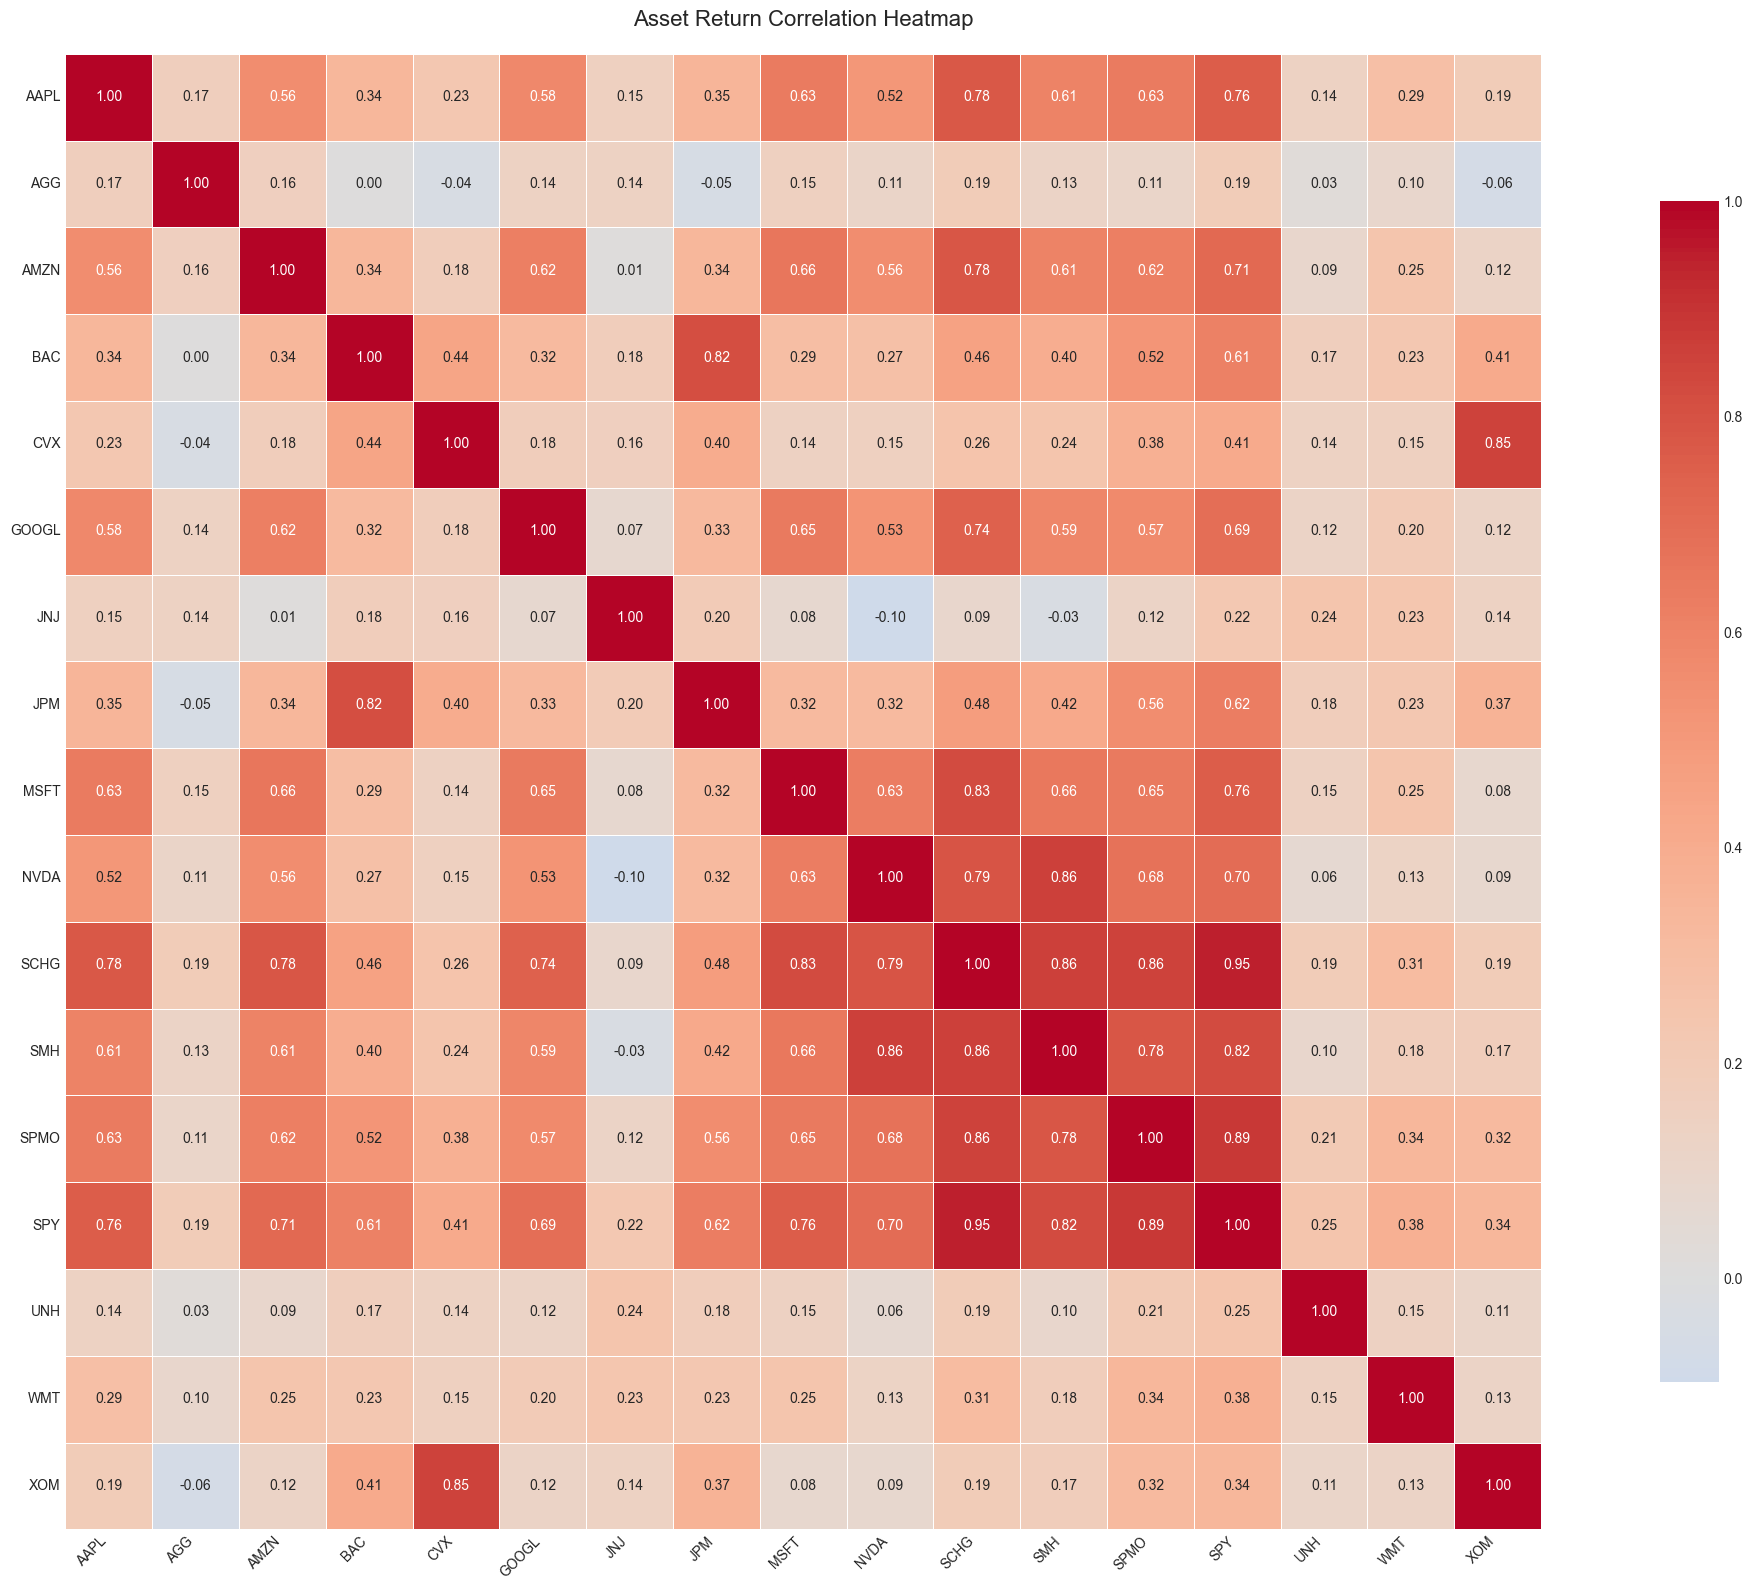

In [8]:
corr_matrix = returns.corr()

plt.figure(figsize=(24, 16))  # Larger figure
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5,
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            square=True, # Make cells square
            cbar_kws={'shrink': 0.8})  # Smaller colorbar
plt.title('Asset Return Correlation Heatmap', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')  # Rotate x labels
plt.yticks(rotation=0)
plt.tight_layout()  # Prevent label cutoff
plt.show()

## Construct a fair portfolio (equal allocation in the porfolio for each ticker)

In [9]:
# riskFreeRate is defined once earlier (with the returns/metrics cell) and reused here.

num_assets = returns.shape[1] #num of stock tickers
equal_weights = np.array([1 / num_assets] * num_assets) #equal weights that add upto one

portfolio_returns_fair = returns @ equal_weights # daily returns of fairly allocated portfolio ( 1 / numStocks)

portfolio_vol_fair = portfolio_returns_fair.std() * np.sqrt(252)  # avg daily standard deviation * 252 for annualized volatility
portfolio_return_fair = portfolio_returns_fair.mean() * 252 # avg daily return * 252 to annualize
portfolio_sharpe_fair = (portfolio_return_fair - riskFreeRate) / portfolio_vol_fair  # excess return over risk-free, per unit volatility
print(f"Annualized volatility: {portfolio_vol_fair}")
print(f"Annualized return:{portfolio_return_fair}")
print(f"Annualized sharpe ratio: {portfolio_sharpe_fair}")

Annualized volatility: 0.1694427808370602
Annualized return:0.21353963801639733
Annualized sharpe ratio: 1.0241784109012986


## Optimize Fair Portfolio 

In [10]:
cov_matrix = returns.cov() * 252

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix.values @ weights)

# sum of weights must be equal to 1
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

#each weight is between 0 and 1; a percentage of the portfolio
bounds = tuple((0, 1) for _ in range(num_assets))

from scipy.optimize import minimize

initial_weights = equal_weights

# minimize portfolio volatility using initial weights according to SLSQP method with bounds within 0 and 1 and the constraint above
opt_result = minimize(
    portfolio_volatility,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

opt_weights = opt_result.x
print(opt_weights)

[0.00000000e+00 8.51534113e-01 0.00000000e+00 5.26152637e-19
 8.72964105e-03 0.00000000e+00 3.80608925e-02 3.54548348e-02
 4.83585627e-18 3.12931703e-18 6.26807049e-18 8.71295822e-18
 2.18307253e-17 0.00000000e+00 1.45914616e-02 2.28156779e-02
 2.88133787e-02]


In [11]:
portfolio_returns_opt = returns @ opt_weights

portfolio_vol_opt = portfolio_returns_opt.std() * np.sqrt(252)
portfolio_return_opt = portfolio_returns_opt.mean() * 252
portfolio_sharpe_opt = (portfolio_return_opt - riskFreeRate) / portfolio_vol_opt  # excess return over risk-free, per unit volatility

print(f"Optimized portfolio's Annualized Volatility:{portfolio_vol_opt}")
print(f"Optimized portfolio's Annualized Return: {portfolio_return_opt}")
print(f"Optimized portfolio's Sharpe Ratio: {portfolio_sharpe_opt}")

Optimized portfolio's Annualized Volatility:0.05613487344187034
Optimized portfolio's Annualized Return: 0.02693685010822989
Optimized portfolio's Sharpe Ratio: -0.23271006222713708


### Risk - Return Results

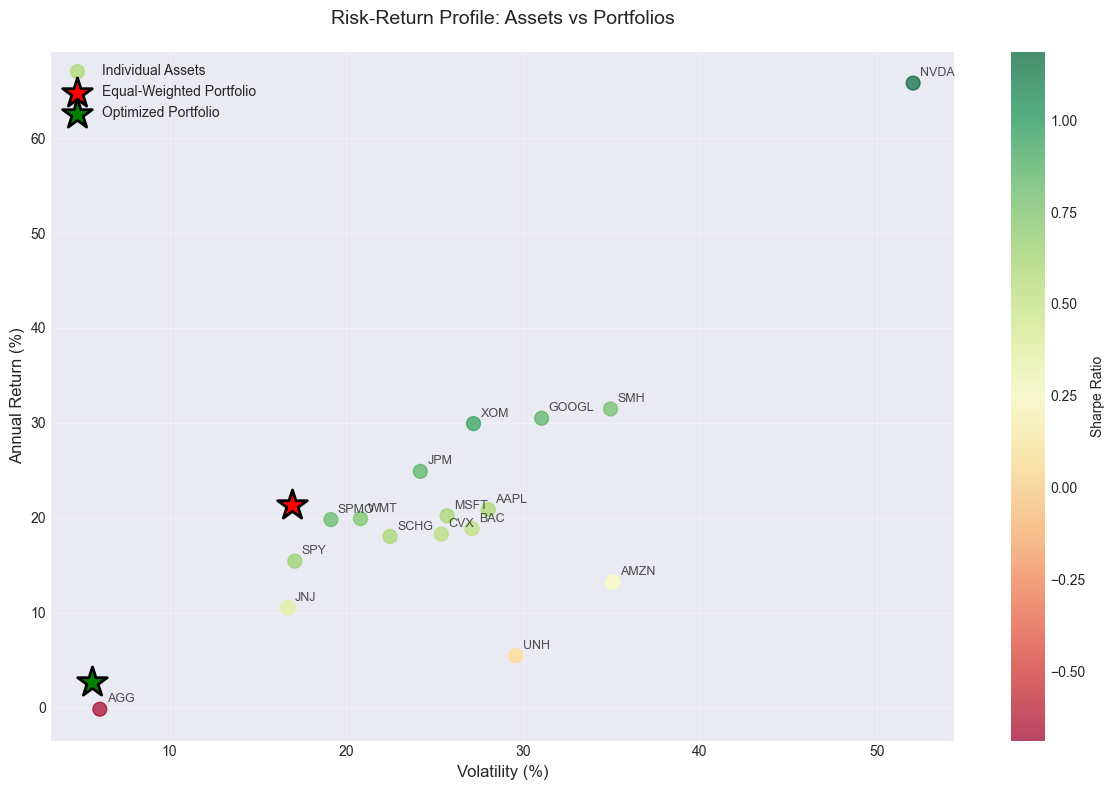

In [12]:
sharpe_ratio = (annual_returns - riskFreeRate) / annual_volatility

# Create the plot
plt.figure(figsize=(12, 8))

# Plot individual assets
plt.scatter(
    annual_volatility * 100,
    annual_returns * 100,
    s=100,
    alpha=0.7,
    c=sharpe_ratio,  # Color by Sharpe ratio
    cmap='RdYlGn',   # Red (low) to Green (high)
    label='Individual Assets'
)
plt.colorbar(label='Sharpe Ratio')

# Annotate each ticker
for ticker in tickers:
    plt.annotate(
        ticker,
        xy=(annual_volatility[ticker] * 100, annual_returns[ticker] * 100),
        xytext=(5, 5),  # Offset the label slightly
        textcoords='offset points',
        fontsize=9,
        alpha=0.8
    )

# Plot portfolios
plt.scatter(
    portfolio_vol_fair * 100,
    portfolio_return_fair * 100,
    marker='*',
    s=500,
    c='red',
    edgecolors='black',
    linewidths=2,
    label='Equal-Weighted Portfolio',
    zorder=5  # Draw on top
)

plt.scatter(
    portfolio_vol_opt * 100,
    portfolio_return_opt * 100,
    marker='*',
    s=500,
    c='green',
    edgecolors='black',
    linewidths=2,
    label='Optimized Portfolio',
    zorder=5
)

plt.xlabel('Volatility (%)', fontsize=12)
plt.ylabel('Annual Return (%)', fontsize=12)
plt.title('Risk-Return Profile: Assets vs Portfolios', fontsize=14, pad=20)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



##  1: Feature Engineering

### Create predictive features from historical data:

In [13]:
def create_features(data, returns, ticker):

    df = pd.DataFrame(index=returns.index)
    print(df.columns)
    # Momentum 
    df['return_5d'] = returns[ticker].rolling(5).mean()
    df['return_20d'] = returns[ticker].rolling(20).mean()
    df['return_60d'] = returns[ticker].rolling(60).mean()
    
    # Volatility 
    df['volatility_20d'] = returns[ticker].rolling(20).std()
    df['volatility_60d'] = returns[ticker].rolling(60).std()
    
    # Volume  (if available)
    # df['volume_ratio'] = volume[ticker] / volume[ticker].rolling(20).mean()
    
    # Market correlation 
    df['corr_to_spy'] = returns[ticker].rolling(60).corr(returns['SPY'])
    
    # Relative strength
    df['rsi_14'] = calculate_rsi(returns[ticker], periods=14)
    
    return df.dropna()

# Answers the question: How strong are the gains compared to the losses over a period?
# also a momentum indicator 
def calculate_rsi(returns, periods=14):
    delta = returns
    gain = (delta.where(delta > 0, 0)).rolling(window = periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window = periods).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

### Create target variable (in this case, SPY)

In [14]:
def create_target(returns, ticker, forward_window=20):
    """
    Will this stock outperform SPY in next 20 days? => 1 if yes, 0 if no
    """
    # forward returns
    forward_return_stock = returns[ticker].shift(-forward_window).rolling(forward_window).sum()
    forward_return_spy = returns['SPY'].shift(-forward_window).rolling(forward_window).sum()
    
    target = (forward_return_stock > forward_return_spy).astype(int)
    
    return target

### Combine Features & Target

In [15]:
# For each stock, create dataset
all_data = []

for ticker in [t for t in tickers if t not in ['SPY', 'QQQ']]:
    features = create_features(data, returns, ticker)
    target = create_target(returns, ticker, forward_window=20)
    
    # Combine
    stock_data = features.copy()
    stock_data['target'] = target
    stock_data['ticker'] = ticker
    stock_data.dropna(inplace=True)
    
    all_data.append(stock_data)

# Combine all stocks
ml_dataset = pd.concat(all_data, axis=0)

RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)


### Time-based Train-Test Split 

In [16]:
from datetime import timedelta

end_date = pd.to_datetime(end_date)  
test_days = 120  # Last 120 days for testing
split_date = end_date - pd.Timedelta(days=test_days) #split date to determine test/train

train = ml_dataset[ml_dataset.index < split_date]
test = ml_dataset[ml_dataset.index >= split_date]

X_train = train.drop(['target', 'ticker'], axis=1)
y_train = train['target']

X_test = test.drop(['target', 'ticker'], axis=1)
y_test = test['target']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Positive class %: {y_train.mean():.2%}")

Training samples: 17856
Test samples: 1344
Positive class %: 52.46%


## Training

In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

#### Benchmark Models

In [18]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)

#### XGBoost

In [19]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)

# Compare
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC': [lr_auc, rf_auc, xgb_auc]
}).sort_values('ROC-AUC', ascending=False)

print(results)

                 Model   ROC-AUC
2              XGBoost  0.557398
0  Logistic Regression  0.518118
1        Random Forest  0.517531


## Validation

Top 5 Features:
          Feature  Importance
4  volatility_60d    0.206506
5     corr_to_spy    0.186527
3  volatility_20d    0.167221
2      return_60d    0.130835
6          rsi_14    0.116269
              precision    recall  f1-score   support

           0       0.62      0.51      0.56       788
           1       0.45      0.57      0.50       556

    accuracy                           0.53      1344
   macro avg       0.54      0.54      0.53      1344
weighted avg       0.55      0.53      0.54      1344



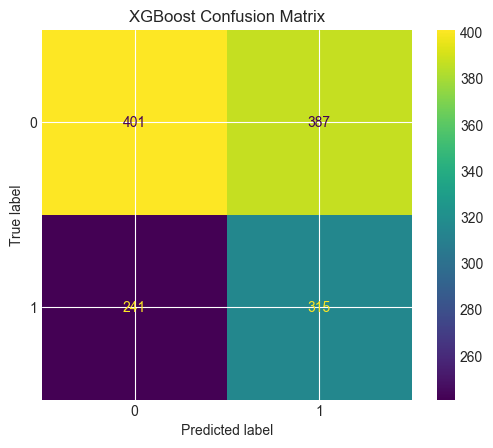

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 5 Features:")
print(feature_importance.head())

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, xgb.predict(X_test)))

# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)
plt.title('XGBoost Confusion Matrix')
plt.show()

### Use Predictions for Portfolio

In [21]:
# Form ML-based weights from features at the START of the test window (point-in-time, no look-ahead).
# Each feature row uses only backward-looking rolling windows, so the row dated at the start of the
# test window knows nothing about the test period's outcomes.
# (Previously weights came from features.iloc[-1:] -- the END of the sample, i.e. future data.)
stock_tickers = [t for t in tickers if t not in ['SPY', 'QQQ']]

preds_oos = {}   # as of start of test window (point-in-time, correct)
preds_eos = {}   # as of end of sample (look-ahead, kept only for the before/after comparison)

for ticker in stock_tickers:
    features = create_features(data, returns, ticker)        # full history of feature rows
    test_features = features[features.index >= split_date]   # rows inside the test window

    if len(test_features) > 0:
        # first available feature row on/after the split date == start of test window
        preds_oos[ticker] = xgb.predict_proba(test_features.iloc[0:1])[0, 1]
    if len(features) > 0:
        preds_eos[ticker] = xgb.predict_proba(features.iloc[-1:])[0, 1]

def to_full_weights(preds):
    """Normalize outperformance probabilities to sum to 1, then expand to all tickers (SPY/AGG-safe)."""
    w_stocks = pd.Series(preds)
    w_stocks = w_stocks / w_stocks.sum()
    w_full = pd.Series(0.0, index=tickers)
    w_full[w_stocks.index] = w_stocks
    return w_stocks, w_full

# Primary (out-of-sample) weights used by the backtest:
ml_weights_stocks, ml_weights_full = to_full_weights(preds_oos)
# End-of-sample weights, kept only to show how much look-ahead inflated the previous result:
ml_weights_stocks_eos, ml_weights_full_eos = to_full_weights(preds_eos)

print("\nML-Based Portfolio Weights (point-in-time, formed at start of test window):")
print(ml_weights_stocks.sort_values(ascending=False))
print(f"\nTotal weight allocated: {ml_weights_stocks.sum():.2f}")
print(f"Weights formed as of test start: {returns[returns.index >= split_date].index[0].date()}")

RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)


RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)
RangeIndex(start=0, stop=0, step=1)

ML-Based Portfolio Weights (point-in-time, formed at start of test window):
UNH      0.108554
JNJ      0.088426
SCHG     0.081876
SMH      0.076576
AAPL     0.073763
BAC      0.063873
CVX      0.063012
AMZN     0.061146
GOOGL    0.060070
XOM      0.057401
NVDA     0.056943
JPM      0.053939
SPMO     0.045068
MSFT     0.044305
AGG      0.034825
WMT      0.030224
dtype: float32

Total weight allocated: 1.00
Weights formed as of test start: 2025-08-08


## Backtest ML Portfolio

In [22]:
from scipy.optimize import minimize

# Split returns at the same split_date. Evaluation is held fixed on test_returns;
# only the WEIGHTS differ between the previous (look-ahead) and out-of-sample versions.
train_returns = returns[returns.index < split_date]
test_returns = returns[returns.index >= split_date]
print(f"Train window: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} trading days)")
print(f"Test  window: {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} trading days)")

def annualized_metrics(daily_returns):
    annual_return = daily_returns.mean() * 252
    annual_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (annual_return - riskFreeRate) / annual_vol  # excess return over risk-free, per unit volatility
    return annual_return, annual_vol, sharpe

# --- Min-variance weights estimated on the TRAIN window only (no future data) ---
cov_train = train_returns.cov() * 252
def _train_volatility(w):
    return np.sqrt(w.T @ cov_train.values @ w)
opt_train = minimize(_train_volatility, equal_weights, method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights_train = opt_train.x

def build_table(ml_w, mv_w, label):
    table = pd.DataFrame({
        'ML Portfolio': annualized_metrics(test_returns @ ml_w),
        'Equal Weight': annualized_metrics(test_returns @ equal_weights),  # 1/N, no estimation -> identical in both versions
        'Min Variance': annualized_metrics(test_returns @ mv_w),
    }, index=['Annual Return', 'Volatility', 'Sharpe Ratio'])
    print(f"\n{label}")
    print("="*60)
    print(table.round(4))
    return table

# PREVIOUS: weights peek at the future (ML from end-of-sample features, MV optimized on full period)
prev = build_table(ml_weights_full_eos, opt_weights, "PREVIOUS (look-ahead weights, evaluated on test window):")

# OUT-OF-SAMPLE: ML weights from start-of-test features, MV optimized on train window only
oos = build_table(ml_weights_full, opt_weights_train, "OUT-OF-SAMPLE (train-only / point-in-time weights):")

# Report how each strategy's Sharpe changes
print("\nSharpe Ratio change: out-of-sample vs previous")
print("="*60)
sharpe_change = pd.DataFrame({
    'Previous Sharpe': prev.loc['Sharpe Ratio'],
    'OOS Sharpe': oos.loc['Sharpe Ratio'],
})
sharpe_change['Change'] = sharpe_change['OOS Sharpe'] - sharpe_change['Previous Sharpe']
print(sharpe_change.round(4))

Train window: 2020-12-02 to 2025-08-07 (1175 trading days)
Test  window: 2025-08-08 to 2025-12-05 (84 trading days)

PREVIOUS (look-ahead weights, evaluated on test window):
               ML Portfolio  Equal Weight  Min Variance
Annual Return        0.4164        0.4071        0.1216
Volatility           0.1138        0.1072        0.0323
Sharpe Ratio         3.3071        3.4229        2.5213

OUT-OF-SAMPLE (train-only / point-in-time weights):
               ML Portfolio  Equal Weight  Min Variance
Annual Return        0.4797        0.4071        0.1254
Volatility           0.1155        0.1072        0.0328
Sharpe Ratio         3.8055        3.4229        2.6062

Sharpe Ratio change: out-of-sample vs previous
              Previous Sharpe  OOS Sharpe  Change
ML Portfolio           3.3071      3.8055  0.4984
Equal Weight           3.4229      3.4229  0.0000
Min Variance           2.5213      2.6062  0.0849


## Compare Optimization Strategies (Min Variance vs Max Sharpe vs Risk Parity)

All weights are estimated on the **train** window only and evaluated forward on the **test** window, with equal-weight as the baseline.

In [23]:
# Two more train-only optimizers alongside min-variance, using the SAME SLSQP pattern
# (same bounds [0,1] and sum-to-1 constraint) and evaluated forward on the test window.
# Reuses from the backtest cell above: train_returns, test_returns, cov_train,
# opt_weights_train (min-variance), annualized_metrics, equal_weights, bounds, constraints, num_assets.
mean_train = train_returns.mean() * 252   # annualized expected returns, train window only

# --- Max-Sharpe: maximize (w·mean - rf)/vol  ==  minimize the NEGATIVE Sharpe ---
def neg_sharpe(w):
    port_return = w @ mean_train.values
    port_vol = np.sqrt(w @ cov_train.values @ w)
    return -(port_return - riskFreeRate) / port_vol

max_sharpe_res = minimize(neg_sharpe, equal_weights, method='SLSQP',
                          bounds=bounds, constraints=constraints)
max_sharpe_weights = max_sharpe_res.x

# --- Risk parity: each asset contributes equally to total portfolio variance ---
# Asset i's contribution to total variance is w_i * (cov·w)_i; these sum to w·cov·w.
# Minimize the squared deviation of each asset's FRACTIONAL contribution from 1/N
# (fractional form is scale-free, so SLSQP converges cleanly).
def risk_parity_objective(w):
    cov = cov_train.values
    port_var = w @ cov @ w
    rc_frac = (w * (cov @ w)) / port_var          # fractional risk contributions, sum to 1
    return np.sum((rc_frac - 1.0 / num_assets) ** 2)

risk_parity_res = minimize(risk_parity_objective, equal_weights, method='SLSQP',
                           bounds=bounds, constraints=constraints)
risk_parity_weights = risk_parity_res.x

# --- Evaluate all four strategies forward on the SAME test window ---
strategy_weights = {
    'Equal Weight': equal_weights,        # baseline, no estimation
    'Min Variance': opt_weights_train,    # train-only (from backtest cell)
    'Max Sharpe':   max_sharpe_weights,   # train-only
    'Risk Parity':  risk_parity_weights,  # train-only
}

strategy_comparison = pd.DataFrame(
    {name: annualized_metrics(test_returns @ w) for name, w in strategy_weights.items()},
    index=['Annual Return', 'Volatility', 'Sharpe Ratio'],
)

print("Strategy Comparison (train-only weights, evaluated forward on the test window):")
print(f"Train: {train_returns.index[0].date()} to {train_returns.index[-1].date()}  |  "
      f"Test: {test_returns.index[0].date()} to {test_returns.index[-1].date()}")
print("="*60)
print(strategy_comparison.round(4))

Strategy Comparison (train-only weights, evaluated forward on the test window):
Train: 2020-12-02 to 2025-08-07  |  Test: 2025-08-08 to 2025-12-05
               Equal Weight  Min Variance  Max Sharpe  Risk Parity
Annual Return        0.4071        0.1254      0.2920       0.3205
Volatility           0.1072        0.0328      0.1118       0.0658
Sharpe Ratio         3.4229        2.6062      2.2547       4.2631


## Monte Carlo Efficient Frontier

Sample 10,000 random long-only portfolios (Dirichlet weights) on the **train** window — the same `mean_train` / `cov_train` the optimizers were fit on — so the random cloud and the four strategy points live on identical return/volatility axes. The frontier is the upper-left edge of the cloud; the train-only SLSQP optimizers should sit on or just inside it, and the random search should approach but not beat the Max-Sharpe optimizer.

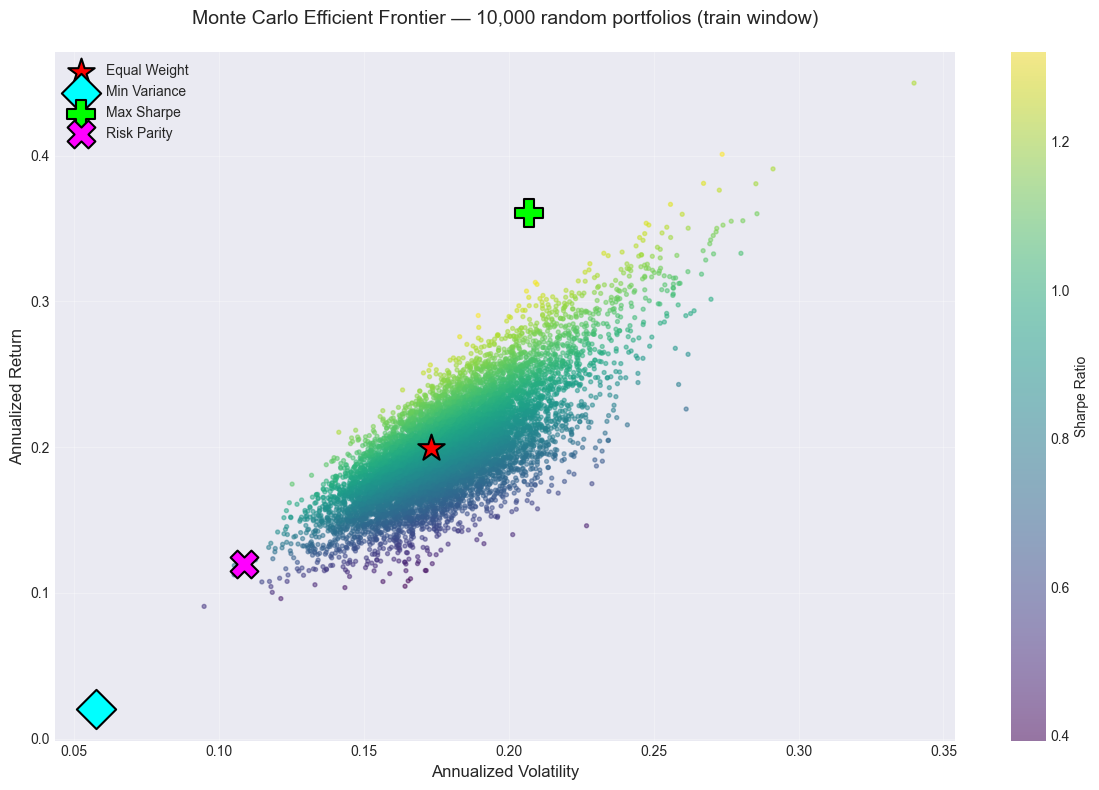

Max-Sharpe point found by random search (train window):
  Return 0.2903 | Vol 0.1895 | Sharpe 1.3212
SLSQP Max-Sharpe optimizer (train window) Sharpe: 1.5508
  Gap (optimizer - random): +0.2296
  -> Random best is close to but does NOT beat the optimizer, as expected.


In [24]:
# Monte Carlo efficient frontier on the TRAIN window.
# Reuses from the cells above: mean_train, cov_train (both already annualized x252),
# num_assets, riskFreeRate, annualized_metrics, train_returns, and the four strategy weights.
np.random.seed(42)  # reproducible random search
n_portfolios = 10_000

# Dirichlet(alpha=1) gives weights that are non-negative and sum to 1 (uniform over the simplex).
mc_weights = np.random.dirichlet(np.ones(num_assets), size=n_portfolios)  # shape (n_portfolios, num_assets)

# Annualized return / vol / Sharpe for every random portfolio, computed the SAME way as
# annualized_metrics(): w @ mean_train and sqrt(w @ cov_train @ w) on the train-window moments.
mc_returns = mc_weights @ mean_train.values
mc_vols = np.sqrt(np.einsum('pi,ij,pj->p', mc_weights, cov_train.values, mc_weights))
mc_sharpe = (mc_returns - riskFreeRate) / mc_vols

# Strategy markers: TRAIN-window return/vol so they sit inside the same cloud.
strategy_points = {
    name: annualized_metrics(train_returns @ w)[:2]   # (annual_return, annual_vol)
    for name, w in strategy_weights.items()
}
strategy_styles = {
    'Equal Weight': ('*', 'red'),
    'Min Variance': ('D', 'cyan'),
    'Max Sharpe':   ('P', 'lime'),
    'Risk Parity':  ('X', 'magenta'),
}

# --- Efficient frontier scatter: volatility (x) vs return (y), colored by Sharpe ---
plt.figure(figsize=(12, 8))
sc = plt.scatter(mc_vols, mc_returns, c=mc_sharpe, cmap='viridis', s=8, alpha=0.5)
plt.colorbar(sc, label='Sharpe Ratio')

for name, (ret, vol) in strategy_points.items():
    marker, color = strategy_styles[name]
    plt.scatter(vol, ret, marker=marker, s=400, c=color,
                edgecolors='black', linewidths=1.5, zorder=5, label=name)

plt.xlabel('Annualized Volatility', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.title(f'Monte Carlo Efficient Frontier — {n_portfolios:,} random portfolios (train window)', fontsize=14, pad=20)
plt.legend(loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Best random portfolio vs the SLSQP Max-Sharpe optimizer (both on train moments) ---
best_idx = mc_sharpe.argmax()
best_sharpe_mc = mc_sharpe[best_idx]
opt_sharpe_train = annualized_metrics(train_returns @ max_sharpe_weights)[2]

print("Max-Sharpe point found by random search (train window):")
print(f"  Return {mc_returns[best_idx]:.4f} | Vol {mc_vols[best_idx]:.4f} | Sharpe {best_sharpe_mc:.4f}")
print(f"SLSQP Max-Sharpe optimizer (train window) Sharpe: {opt_sharpe_train:.4f}")
print(f"  Gap (optimizer - random): {opt_sharpe_train - best_sharpe_mc:+.4f}")
if best_sharpe_mc <= opt_sharpe_train:
    print("  -> Random best is close to but does NOT beat the optimizer, as expected.")
else:
    print("  -> Random search edged out the optimizer (the SLSQP solution is only locally optimal here).")

###  ACF plots of AAPL prices vs returns.

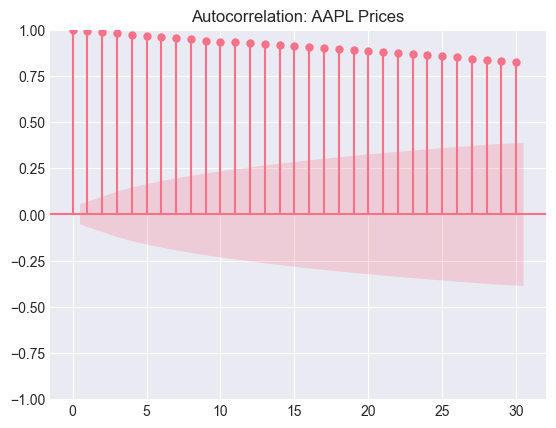

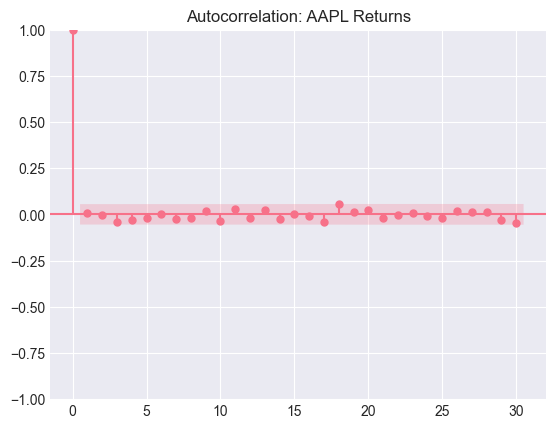

In [25]:
from statsmodels.graphics.tsaplots import plot_acf

# Autocorrelation of PRICES (high)
plot_acf(data['AAPL'].dropna(), lags=30)
plt.title('Autocorrelation: AAPL Prices')
plt.show()

# Autocorrelation of RETURNS (low)
plot_acf(returns['AAPL'].dropna(), lags=30)
plt.title('Autocorrelation: AAPL Returns')
plt.show()

## Final Numbers (Resume Metrics)

One consolidated block of every resume-relevant number: model ROC-AUCs, the four-strategy out-of-sample comparison, volatility reduction vs the equal-weight baseline, the Monte Carlo simulation count, and the test-window dates / trading days. These are printed straight from the live variables — whatever the run actually produces.

In [26]:
# ============================================================
# FINAL NUMBERS - resume-relevant metrics, all in one block.
# Whatever actually comes out of this run (NOT rounded or adjusted for show).
# ============================================================
print("="*70)
print("FINAL SUMMARY - RESUME METRICS")
print("="*70)

# [1] Model ROC-AUC (test window, out-of-sample) ---------------------
print("\n[1] MODEL ROC-AUC (test window)")
print("-"*70)
print(f"  Logistic Regression : {lr_auc:.4f}")
print(f"  Random Forest       : {rf_auc:.4f}")
print(f"  XGBoost             : {xgb_auc:.4f}")

# [2] Four-strategy comparison (out-of-sample, test window) -----------
print("\n[2] FOUR-STRATEGY COMPARISON (train-only weights, evaluated forward on test window)")
print("-"*70)
print(strategy_comparison.round(4).to_string())

# [3] Volatility reduction vs equal-weight baseline ------------------
eq_vol = strategy_comparison.loc['Volatility', 'Equal Weight']
mv_vol = strategy_comparison.loc['Volatility', 'Min Variance']
rp_vol = strategy_comparison.loc['Volatility', 'Risk Parity']
mv_reduction = (eq_vol - mv_vol) / eq_vol * 100
rp_reduction = (eq_vol - rp_vol) / eq_vol * 100
print("\n[3] VOLATILITY REDUCTION vs EQUAL-WEIGHT BASELINE (test window, annualized)")
print("-"*70)
print(f"  Equal-weight volatility : {eq_vol:.4f}")
print(f"  Min-variance volatility : {mv_vol:.4f}")
print(f"  Risk-parity volatility  : {rp_vol:.4f}")
print(f"  Min Variance vs Equal Weight : {mv_reduction:.2f}% volatility reduction")
print(f"  Risk Parity  vs Equal Weight : {rp_reduction:.2f}% volatility reduction")

# [4] Monte Carlo simulation count -----------------------------------
print("\n[4] MONTE CARLO")
print("-"*70)
print(f"  Number of simulations : {n_portfolios:,}  (is 10,000: {n_portfolios == 10_000})")

# [5] Test window ----------------------------------------------------
print("\n[5] TEST WINDOW (out-of-sample evaluation period)")
print("-"*70)
print(f"  Start        : {test_returns.index[0].date()}")
print(f"  End          : {test_returns.index[-1].date()}")
print(f"  Trading days : {len(test_returns)}")
print("="*70)

FINAL SUMMARY - RESUME METRICS

[1] MODEL ROC-AUC (test window)
----------------------------------------------------------------------
  Logistic Regression : 0.5181
  Random Forest       : 0.5175
  XGBoost             : 0.5574

[2] FOUR-STRATEGY COMPARISON (train-only weights, evaluated forward on test window)
----------------------------------------------------------------------
               Equal Weight  Min Variance  Max Sharpe  Risk Parity
Annual Return        0.4071        0.1254      0.2920       0.3205
Volatility           0.1072        0.0328      0.1118       0.0658
Sharpe Ratio         3.4229        2.6062      2.2547       4.2631

[3] VOLATILITY REDUCTION vs EQUAL-WEIGHT BASELINE (test window, annualized)
----------------------------------------------------------------------
  Equal-weight volatility : 0.1072
  Min-variance volatility : 0.0328
  Risk-parity volatility  : 0.0658
  Min Variance vs Equal Weight : 69.46% volatility reduction
  Risk Parity  vs Equal Weight : 3